In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import simulation_engine as engine

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Simulation 2 — Player Count Balance

This simulation runs 1 000 games per player count (6–8) and measures three metrics:

- **Win rate** — what fraction of groups escape before the volcano erupts
- **Average rounds played** — proxy for play time, reported separately for wins and losses
- **Volcano cards remaining on wins** — tension indicator: games won with 1–3 cards left were close calls; 8+ means the eruption was never a real threat

In [2]:
PLAYER_COUNTS = np.array([6, 7, 8])
N_GAMES = 1_000
BASE_SEED = 1

records_by_count = {
    player_count: engine.run_scenario(
        player_count = player_count,
        n_games      = N_GAMES,
        base_seed    = BASE_SEED + i * N_GAMES,
    )
    for i, player_count in enumerate(PLAYER_COUNTS)
}

#### Summary Table

Each row is one player count. The table tracks three dimensions of balance: how often the group wins, how long games last, and how close the volcano came to erupting.

| Column | What it shows | Why it matters | Good range |
|---|---|---|---|
| `n_games` | Total games simulated | Larger samples give more reliable estimates | 1 000+ |
| `wins` | Games won out of `n_games` | Raw count behind the win rate | — |
| `win_rate` | Fraction of games won | Core balance indicator — is the game winnable without being trivial? | 0.50–0.65 for *Volcano Rush* |
| `est_play_time` | Estimated session length in minutes | Derived bottom-up from round structure: `avg_rounds × (2 min fixed overhead + 0.5 min per player)`. The fixed overhead covers mission discussion, complication draw, resolution, and bookkeeping; the per-player term accounts for action decisions and resource management. Both constants can be tuned after a real playtest. | Close to the documented 30–60 min |
| `avg_rounds` | Mean game length across all outcomes | Proxy for play time; includes both wins and losses | Stable across player counts |
| `avg_rounds_on_win` | Mean game length for wins only | Shows how long it takes to build the boat; short wins may indicate the game is too easy | Should be consistent with `avg_rounds_on_loss` |
| `avg_rounds_on_loss` | Mean game length for losses only | Shows when the volcano catches up; very short losses signal early collapse rather than a close race | Should be close to `avg_rounds_on_win` |
| `avg_volcano_remaining_on_win` | Mean volcano cards left when the team escaped | Indicates how close the eruption was on wins; high values mean the game was decided well before the volcano threat became real | Low (1–4) for tension |
| `median_volcano_remaining_on_win` | Median volcano cards left on wins | More robust to outliers than the mean; the primary tension indicator | Low (1–4) for tension |
| `median_rounds_gap` | Median rounds on loss − Median rounds on win | Measures tension: how similar are wins and losses in length? A small positive value means losses drag on slightly longer than wins, which feels fair — the team kept fighting until the end. A large positive value means losses are frustratingly long. A negative value means the team collapses early on losses, which feels punishing rather than tense. | Small positive (1–3 rounds) |

In [3]:
BASE_MINUTES_PER_ROUND = 2.0   # fixed overhead per round (discussion, draw, resolution, bookkeeping)
MINUTES_PER_PLAYER = 0.5   # additional time per player for action decisions and resource management

results = pd.DataFrame([
    {
        "player_count": player_count,
        "outcome": record.outcome,
        "rounds_played": record.rounds_played,
        "boat_parts_built": record.boat_parts_built,
        "boat_parts_required": record.boat_parts_required,
        "volcano_cards_remaining": record.volcano_cards_remaining,
    }
    for player_count, records in records_by_count.items()
    for record in records
])

results["rounds_played_on_win"] = results["rounds_played"].where(results["outcome"] == "win")
results["rounds_played_on_loss"] = results["rounds_played"].where(results["outcome"] == "loss")
results["volcano_remaining_on_win"] = results["volcano_cards_remaining"].where(results["outcome"] == "win")
results["is_win"] = results["outcome"].eq("win").astype(int)

summary = (
    results.groupby("player_count")
    .agg(
        n_games                         = ("outcome", "size"),
        wins                            = ("is_win", "sum"),
        avg_rounds                      = ("rounds_played", "mean"),
        avg_rounds_on_win               = ("rounds_played_on_win", "mean"),
        avg_rounds_on_loss              = ("rounds_played_on_loss", "mean"),
        median_rounds_on_win            = ("rounds_played_on_win", "median"),
        median_rounds_on_loss           = ("rounds_played_on_loss", "median"),
        avg_volcano_remaining_on_win    = ("volcano_remaining_on_win", "mean"),
        median_volcano_remaining_on_win = ("volcano_remaining_on_win", "median"),
    )
    .reindex(PLAYER_COUNTS)
).reset_index()

summary["win_rate"] = (summary["wins"] / summary["n_games"]).round(3)
summary["median_rounds_gap"] = (summary["median_rounds_on_loss"] - summary["median_rounds_on_win"]).astype(int)

minutes_per_round = BASE_MINUTES_PER_ROUND + MINUTES_PER_PLAYER * summary["player_count"]
estimated_minutes = (summary["avg_rounds"] * minutes_per_round).round().astype(int)
summary["est_play_time"] = estimated_minutes.astype(str) + " min"

float_cols = [
    "avg_rounds",
    "avg_rounds_on_win",
    "avg_rounds_on_loss",
    "avg_volcano_remaining_on_win",
]

int_cols = ["median_volcano_remaining_on_win", "median_rounds_gap"]

summary[float_cols] = summary[float_cols].round(1)
summary[int_cols] = summary[int_cols].round(0).astype(int)

summary = summary[[
    "player_count",
    "n_games",
    "wins",
    "win_rate",
    "est_play_time",
    "avg_rounds",
    "avg_rounds_on_win",
    "avg_rounds_on_loss",
    "avg_volcano_remaining_on_win",
    "median_volcano_remaining_on_win",
    "median_rounds_gap",
]]

summary

,player_count,n_games,wins,win_rate,est_play_time,avg_rounds,avg_rounds_on_win,avg_rounds_on_loss,avg_volcano_remaining_on_win,median_volcano_remaining_on_win,median_rounds_gap
0,6,1000,855,0.855,78 min,15.5,15.2,17.2,4.4,4,2
1,7,1000,899,0.899,87 min,15.9,15.7,17.9,5.4,5,2
2,8,1000,950,0.950,85 min,14.1,13.9,18.4,7.3,7,5


#### Win Rate by Player Count

Win rate per player count with 95% Wald confidence intervals. With N = 1 000 games the normal approximation is reliable and the simpler Wald formula applies: $\hat{p} \pm 1.96\sqrt{\hat{p}(1-\hat{p})/n}$.

There is no universally correct win rate for a cooperative game — it depends on the intended experience. As a general guideline:

| Win rate | Feel |
|---|---|
| > 80% | Easy — the game rarely challenges the group |
| 65–80% | Accessible — most sessions end in a win |
| 50–65% | Challenging — wins feel earned; losses are plausible |
| 35–50% | Hard — losses are the norm; high-skill ceiling |
| < 35% | Punishing — only experienced or lucky groups win |

For *Volcano Rush*, a target of **50–65%** is suggested: the eruption threat should feel real across all player counts, and a loss should never feel unfair.

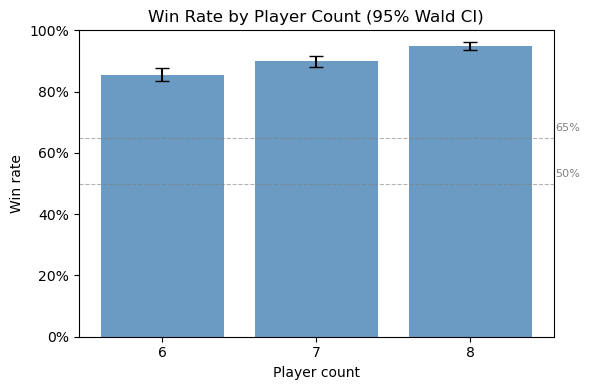

In [4]:
Z_SCORE = 1.96

win_rates = summary["win_rate"].values
error_margin = Z_SCORE * np.sqrt(win_rates * (1 - win_rates) / N_GAMES)
player_count_labels = PLAYER_COUNTS.astype(str)

# Position threshold labels slightly to the right of the last bar
threshold_label_x = len(PLAYER_COUNTS) - 0.45

plt.figure(figsize = (6, 4))

plt.bar(player_count_labels, win_rates, color = "steelblue", alpha = 0.8, zorder = 2)
plt.errorbar(
    player_count_labels, win_rates,
    yerr    = [error_margin, error_margin],
    fmt     = "none",
    color   = "black",
    capsize = 5,
    zorder  = 3,
)

# Add horizontal lines and labels for 50% and 65% thresholds
for threshold, label in [(0.5, "50%"), (0.65, "65%")]:
    plt.axhline(threshold, linestyle = "--", color = "gray", linewidth = 0.8, alpha = 0.6)
    plt.text(threshold_label_x, threshold + error_margin.max(), label, fontsize = 8, color = "gray")

plt.xlabel("Player count")
plt.ylabel("Win rate")
plt.title("Win Rate by Player Count (95% Wald CI)")
plt.ylim(0, 1)

plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax = 1))

plt.tight_layout()
plt.show()

#### Rounds Played by Outcome

Each box shows the distribution of game length for a given player count and outcome. The middle line is the median, the box covers the middle 50% of games (25th–75th percentile), whiskers extend to the full range, and dots are outliers. Green boxes are wins, red boxes are losses.

- If the red box sits **lower** than the green one, losses tend to happen early — the team ran out of resources or missions quickly. If it sits **higher**, games dragged on before the volcano finally erupted.
- If the green box is **tight**, winning games finish in a predictable number of rounds. If it is **wide**, some wins are fast and some are slow.
- Comparing across player counts shows whether more players make games longer or shorter, and whether that effect differs between wins and losses.

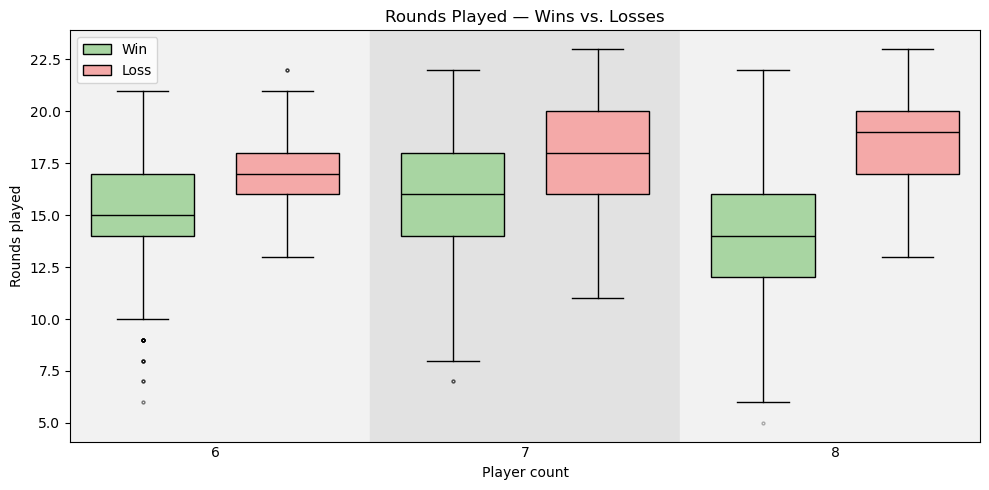

In [5]:
win_rounds = [
    results[(results["player_count"] == player_count) & (results["outcome"] == "win")]["rounds_played"].values
    for player_count in PLAYER_COUNTS
]
loss_rounds = [
    results[(results["player_count"] == player_count) & (results["outcome"] == "loss")]["rounds_played"].values
    for player_count in PLAYER_COUNTS
]

player_count_labels = PLAYER_COUNTS.astype(str)
group_centers = np.arange(len(PLAYER_COUNTS)) * 3
box_width = 1.0
box_offset = 0.7
positions_win = group_centers - box_offset
positions_loss = group_centers + box_offset

x_padding = box_offset + box_width / 2 + 0.2
x_min = group_centers[0] - x_padding
x_max = group_centers[-1] + x_padding

midpoints = (group_centers[:-1] + group_centers[1:]) / 2
band_edges = np.concatenate([[x_min], midpoints, [x_max]])

band_colors = ["#f2f2f2", "#e2e2e2"]

plt.figure(figsize = (10, 5))
plt.gca().xaxis.grid(False)

for i in range(len(group_centers)):
    plt.axvspan(band_edges[i], band_edges[i + 1], color = band_colors[i % 2], zorder = 0)

bp_win = plt.boxplot(
    win_rounds,
    positions    = positions_win,
    widths       = box_width,
    patch_artist = True,
    boxprops     = {"facecolor": "#a8d5a2", "color": "black"},
    medianprops  = {"color": "black"},
    flierprops   = {"marker": "o", "markersize": 2, "alpha": 0.3},
    whiskerprops = {"color": "black"},
    capprops     = {"color": "black"},
)
bp_loss = plt.boxplot(
    loss_rounds,
    positions    = positions_loss,
    widths       = box_width,
    patch_artist = True,
    boxprops     = {"facecolor": "#f4a9a8", "color": "black"},
    medianprops  = {"color": "black"},
    flierprops   = {"marker": "o", "markersize": 2, "alpha": 0.3},
    whiskerprops = {"color": "black"},
    capprops     = {"color": "black"},
)

plt.xticks(group_centers, player_count_labels)
plt.tick_params(axis = "x", length = 0)
plt.xlim(x_min, x_max)
plt.xlabel("Player count")
plt.ylabel("Rounds played")
plt.title("Rounds Played — Wins vs. Losses")
plt.legend([bp_win["boxes"][0], bp_loss["boxes"][0]], ["Win", "Loss"])

plt.tight_layout()
plt.show()

#### Volcano Cards Remaining at Win (Tension)

How many penalty cards were left undrawn when the winning team escaped. Low values mean the eruption was inevitable — the win was a close call. High values mean the group was never under real pressure.

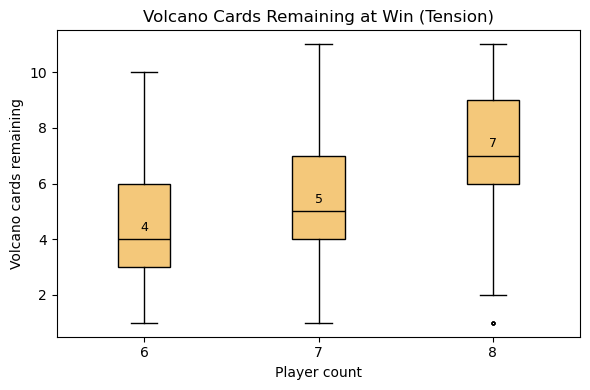

In [6]:
volcano_remaining_on_wins = [
    results[(results["player_count"] == player_count) & (results["outcome"] == "win")]["volcano_cards_remaining"].values
    for player_count in PLAYER_COUNTS
]

player_count_labels = PLAYER_COUNTS.astype(str)

plt.figure(figsize = (6, 4))

bp_tension = plt.boxplot(
    volcano_remaining_on_wins,
    patch_artist = True,
    boxprops     = {"facecolor": "#f4c87a", "color": "black"},
    medianprops  = {"color": "black"},
    flierprops   = {"marker": "o", "markersize": 2, "alpha": 0.3},
    whiskerprops = {"color": "black"},
    capprops     = {"color": "black"},
)

medians = np.array([np.median(values) for values in volcano_remaining_on_wins])
for i, median_value in enumerate(medians):
    plt.text(i + 1, median_value + 0.3, f"{median_value:.0f}", ha = "center", fontsize = 9)

plt.xticks(np.arange(1, len(PLAYER_COUNTS) + 1), player_count_labels)
plt.xlabel("Player count")
plt.ylabel("Volcano cards remaining")
plt.title("Volcano Cards Remaining at Win (Tension)")

plt.tight_layout()
plt.show()